# 0x06. Quantum Teleportation Simulation


## 🎯 Learning Objectives

At the end of this project, you are expected to be able to explain to anyone, without the help of Google:

- **The No-Cloning theorem**  
  Why it makes quantum communication fundamentally different from classical data copying.

- **Bell Measurement**  
  What it is and why it destroys the original quantum state.

- **Quantum teleportation and relativity**  
  Why teleportation cannot happen faster than the speed of light (the necessity of the classical channel).

- **Corrective operations**  
  How to use the results of classical bits to apply corrective Pauli-X and Pauli-Z gates to the receiving qubit.


### Task 0: The Teleportation Protocol Setup

#### ⚙️ Protocol Setup: Message, Sender (Alice), Receiver (Bob)

- [ ] **Open a new Jupyter Notebook**  
  Import Qiskit to begin working with quantum circuits.

- [ ] **Create a quantum circuit**  
  - 3 qubits:  
    - **Q0** → the message qubit  
    - **Q1** → Alice’s half of the entangled pair  
    - **Q2** → Bob’s half of the entangled pair  
  - 2 classical bits for measurement results.

- [ ] **Output the circuit**  
  Use `circuit.draw()` to visualize your setup, showing the three qubits and the classical register ready to go.


In [10]:
#import libraries

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate, ZGate


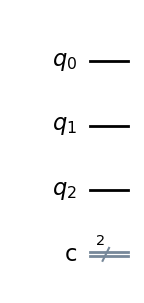

In [11]:
qc = QuantumCircuit(3,2)
qc.draw("mpl")

#### Task 1: The Entangled Link

Establish the "quantum telephone line" between the sender and receiver before any message is sent.

- [ ] **Create a Bell state (entanglement)**  
  Use an **H-gate** on Alice’s qubit (Q1), followed by a **CNOT-gate** with Q1 as control and Bob’s qubit (Q2) as target.

- [ ] **Output**  
  Your circuit should show Q1 and Q2 entangled, while Q0 (the message qubit) remains untouched.


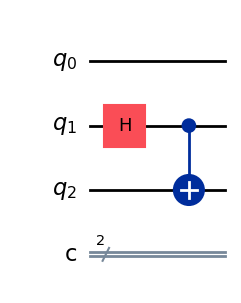

In [12]:
qc.h(1)
qc.cx(1,2)
qc.draw("mpl")

#### Task 2: Preparing the Payload

Create the distinct quantum state that Alice wants to teleport to Bob.

- [ ] **Apply a sequence of gates**  
  Use an **X-gate** or a specific rotation gate on Q0 to give it a unique, verifiable state (for example, the state ∣1⟩).

- [ ] **Add a visual barrier**  
  Insert `circuit.barrier()` to clearly separate the preparation phase from the teleportation phase.


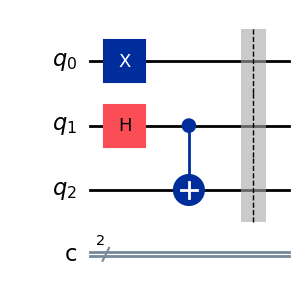

In [13]:
qc.x(0)
qc.barrier()
qc.draw("mpl")

#### Task 3: The Bell Measurement

Alice now entangles her message qubit with her half of the shared pair.

- [ ] **Entangle message and Alice’s qubit**  
  Apply a **CNOT gate** with Q0 (message) as control and Q1 (Alice’s qubit) as target.

- [ ] **Superposition step**  
  Apply a **Hadamard gate** to Q0.

- [ ] **Perform measurement**  
  Measure Q0 and Q1, storing the results in the two classical bits.

- [ ] **Output**  
  The circuit should show Q0 entangled with Q1, followed by their measurement.  
  *Note: Q0’s original quantum state is now destroyed.*


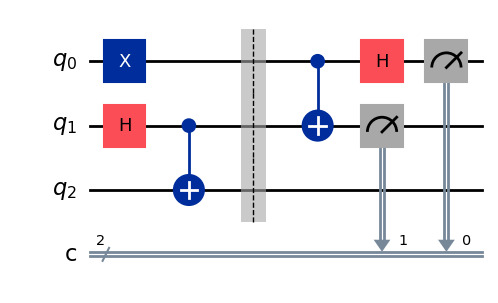

In [14]:
qc.cx(0,1)
qc.h(0)

qc.measure(0,0)
qc.measure(1,1)

qc.draw("mpl")

#### Task 4: Classical Communication & Correction

Bob uses Alice’s measurement results to recover the teleported state.

- [ ] **Add conditional operations**  
  - If Q1 is measured as `1`, apply an **X-gate** to Q2.  
  - If Q0 is measured as `1`, apply a **Z-gate** to Q2.

- [ ] **Output**  
  The circuit should display these corrections applied conditionally, using Qiskit’s `c_if` method to represent the classical communication step.


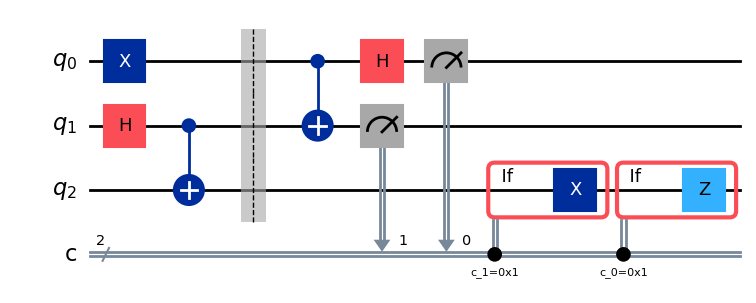

In [15]:
# x_gate = qc.x(2)
# x_gate.c_if(qc.clbits[1],1)

# z_gate = qc.z(2)
# z_gate.c_if(qc.clbits[0],1)

# Attribute error

# qc.append(XGate(), [2]).c_if(1, 1)
# qc.append(ZGate(), [2]).c_if(0, 1)

with qc.if_test((qc.clbits[1],1)):
    qc.x(2)

with qc.if_test((qc.clbits[0], 1)):
    qc.z(2)


qc.draw("mpl")

#### Task 5: Verification

Prove the teleportation was successful.

- [ ] **Add a final measurement**  
  Measure Bob’s qubit (Q2) into a new classical bit.

- [ ] **Simulate the circuit**  
  Use `QasmSimulator` to run the teleportation protocol.

- [ ] **Output**  
  The final measurement of Q2 should match the state you prepared for Q0 in Task 2, confirming successful teleportation.


Teleportation results: {'1 10': 1}


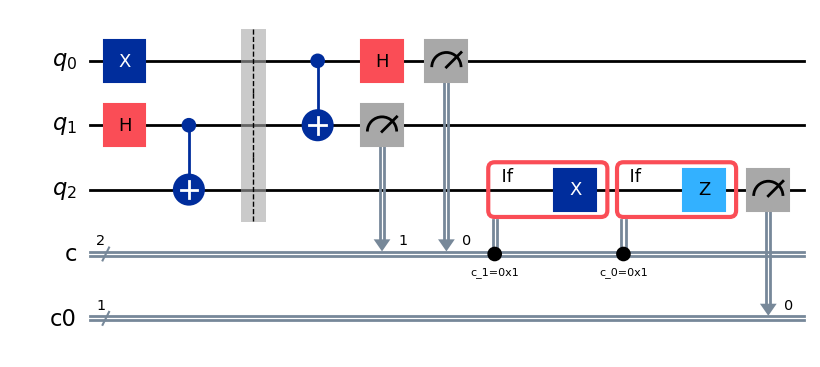

In [16]:
qc.add_register(ClassicalRegister(1))
qc.measure(2,2)
sim = AerSimulator()

result = sim.run(qc, shots=1).result()
counts = result.get_counts()

print("Teleportation results:", counts)
qc.draw('mpl')

In [17]:
# Print with labels
for outcome, freq in counts.items():
    # outcome is a string like '1 10'
    bits = outcome.replace(" ", "")  # remove spaces
    alice_bits = bits[1:]  # first two bits (c1c0)
    bob_bit = bits[0]      # last bit (c2)
    print(f"Alice measured: {alice_bits}, Bob measured: {bob_bit}, frequency: {freq}")

Alice measured: 10, Bob measured: 1, frequency: 1
